In [1]:
import numpy as np
import matplotlib.pyplot as plt
from langevin_samplers import (run_hmc,run_k_langevin,run_od_langevin, several_runs) 

In [2]:
def gradU_zero(x):
    return np.zeros_like(x)


def compute_msd_from_ensemble(X_ensemble):
    """
    X_ensemble: shape (n_traj, n_steps, d)
    Returns:
        msd(t) averaged over trajectories and dimensions
    """
    # displacement from initial point (which is 0 if x0=0)
    disp = X_ensemble - X_ensemble[:, 0:1, :]
    msd = np.mean(disp**2, axis=(0,2))  # average over traj + dim
    return msd

In [3]:
# parameters
d = 1
x0 = np.zeros(d)
v0 = np.random.randn(d)

delta = 0.01
K = 1
N = 20000        # number of outer iterations
n_traj = 2000    # number of independent trajectories

# kinetic Langevin sampler
X_ensemble, V_ensemble = several_runs(
    x0, v0, gradU_zero,
    run_k_langevin,
    n=n_traj,
    N=N,
    delta=delta,
    K=K,
    eta=None
)

msd = compute_msd_from_ensemble(X_ensemble)

# time axis (you store every Verlet step)
n_steps = X_ensemble.shape[1]
t = delta * np.arange(n_steps)

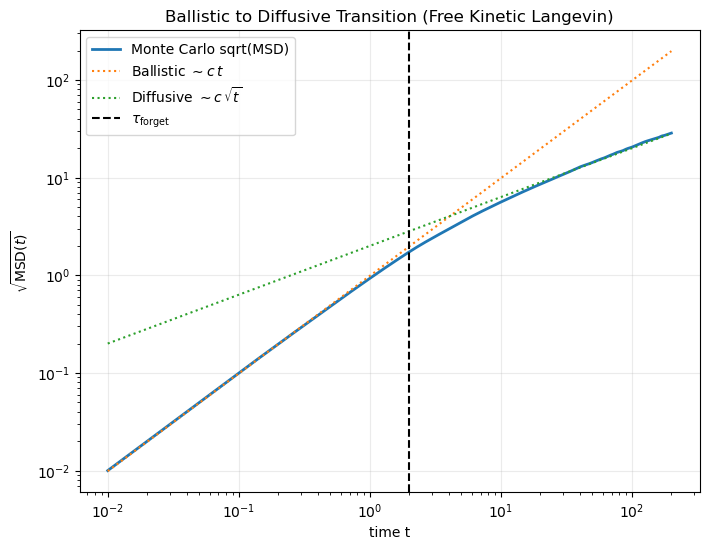

: 

In [ ]:
# === guide line prefactors ===
T = K * delta

# use the eta you actually used in the run:
# - if you ran run_k_langevin with eta=None, then eta_used = exp(-0.5*delta)
# - otherwise use your chosen eta
eta_used = np.exp(-0.5 * delta)  # <-- adjust if you actually passed a different eta

# forgetting time (more consistent for the splitting scheme is T/(1-eta), but keep yours if K=1)
tau_forget = T / (1 - eta_used)

# ballistic prefactor (fit from an early-time point)
idx_ref = 20  # pick an index well before tau_forget
c_ball = np.sqrt(msd[idx_ref]) / t[idx_ref]
ballistic = c_ball * t

# diffusive prefactor (theoretical for your scheme)
c_diff = np.sqrt(T * (1 + eta_used) / (1 - eta_used))
diffusive = c_diff * np.sqrt(t)

# === plot ===
plt.figure(figsize=(8,6))
plt.loglog(t[1:], np.sqrt(msd[1:]), label="Monte Carlo sqrt(MSD)", linewidth=2)
plt.loglog(t[1:], ballistic[1:], ":", label=r"Ballistic $\sim c\,t$")
plt.loglog(t[1:], diffusive[1:], ":", label=r"Diffusive $\sim c\,\sqrt{t}$")

plt.axvline(tau_forget, color="k", linestyle="--", label=r"$\tau_{\mathrm{forget}}$")
plt.xlabel("time t")
plt.ylabel(r"$\sqrt{\mathrm{MSD}(t)}$")
plt.title("Ballistic to Diffusive Transition (Free Kinetic Langevin)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()